In [ ]:
from IPython.core.display import HTML
from IPython.core.pylabtools import figsize
from IPython.display import display, Math
import matplotlib as mpl

figsize(17, 2)
mpl.rcParams['agg.path.chunksize'] = 10000

In [ ]:
import numpy as np
import cupy as cp
from numpy.random import normal
import matplotlib.pyplot as plt
from scipy import constants
from numpy.fft import fft, ifft, fftshift, fftfreq

#!pip install OptiCommPy
from optic.models.devices import mzm, photodiode
from optic.plot import eyediagram
from optic.utils import parameters, dBm2W
from optic.dsp.core import firFilter, signal_power, pulseShape, upsample, pnorm, lowPassFIR

## Receptores ópticos e ruído
---

## Sumário
---
- [Introdução](#introdução)
- [Ruído de disparo](#ruído-de-disparo)
- [Ruído térmico](#ruído-térmico)
- [Razão Sinal-Ruído (SNR)](#razão-sinal-ruído-(SNR))
- [Sensitividade de receptores](#sensitividade-de-receptores)
- [Decisor ótimo: avaliando probabilidades](#decisor-ótimo:-avaliando-probabilidades)

### Introdução
---

<center><img src="https://github.com/edsonportosilva/OpticalCommunications/blob/main/jupyter%20notebooks/figuras/Rx_OOK.png?raw=true" width="55%"/></center>
$$\text{Fonte: Anotações do professor Edson}$$


No cenário ideal de uma comunicação óptica, um sinal gerado ou modulado na origem seria transmitido pela fibra até um detector óptico, como um fotodiodo, que geraria pulsos elétricos equivalentes e possibilitaria a recuperação da informação transmitida. Entretanto, no ambiente real, diversas fontes de ruído surgem no sistema, podendo limitar ou até inviabilizar a transmissão e a correta detecção dos dados.


No funcionamento ideal do fotorreceptor, teríamos uma potência do sinal em função do tempo, $P_{in}(t)$, que geraria uma corrente proporcional, utilizada para recuperar o sinal, expressa por:

$$
I_p(t) = R_d \cdot P_{in}(t)
$$

onde:
- $I_p(t)$ é a corrente elétrica gerada,
- $R_d$ é a responsividade do fotodiodo.

Devido às interferências causadas por limitações no equipamento receptor (como imperfeições do fotodiodo) e efeitos térmicos no sistema, dois tipos de ruído devem ser considerados. Esses ruídos geram **correntes adicionais** que se somam à corrente associada ao sinal útil, resultando em uma corrente total:

- **Ruído de disparo** – relacionado à natureza estatística da detecção de fótons.
- **Ruído térmico** – proveniente da agitação térmica dos portadores de carga no receptor.

### Ruído de Disparo
---

Entretanto, o processo físico de detecção no fotodiodo pode gerar ruídos devido às falhas aleatórias na captação dos elétrons, conhecido como ruído de disparo $I_s(t)$, que possui natureza aditiva. Assim, a corrente total pode ser representada por:

$$
I(t) = I_p(t) + I_s(t)
$$

Esse ruído de disparo segue uma distribuição probabilística Poissoniana, mas para sinais intensos, é bem aproximado por uma função gaussiana e estacionária. Isso facilita seus cálculos, pois basta conhecer sua média e variância, podendo ser considerado um ruído branco gaussiano. Sua densidade espectral de potência é constante:

$$
S_{is}(f) = q \overline{I_p}
$$

e a potência do ruído de disparo corresponderá a sua variância $\sigma_{is}^2$que é dada por:

$$
\sigma_{is}^2 = 2q\overline{I_p}B
$$

onde:
- $q$ é a carga do elétron,
- $\overline{I_p}$ é a corrente média,
- $B$ é a largura de banda do receptor.

Além disso, o fotodiodo também apresenta outro tipo de ruído físico: a corrente de escuro $I_d$, que é a corrente gerada mesmo na ausência de luz. Essa corrente também contribui de forma aditiva para o ruído de disparo, alterando a expressão da variância para:

$$
\sigma_{is}^2 = 2q(\overline{I_p} + I_d)B
$$






In [ ]:
Pin_dBm = -1                                      # potência óptica média em dBm
Rd  = 0.5                                                # responsividade em A/W
Id  = 100e-9                                          # corrente de escuro em nA
B   = 10e9                                             # banda do receptor em Hz
fa = 20e9                                 # frequência de amostragem considerada
q  = constants.value("elementary charge")           # carga elementar do elétron

Pin = 10**(Pin_dBm/10)*1e-3              # transforma potência óptica média em W
Ip  = Rd*Pin

# Simulação do Ruído de Disparo (Shot Noise)
Namostras = 100000
σ2_s = 2*q*(Ip + Id)*B
μ = 0
# Uma média diferente de zero significa que há uma componente DC (corrente contínua) no ruído.

σ = np.sqrt(σ2_s)
Is = normal(μ, σ, Namostras)

def gaussian(x, μ, σ):
    return np.exp(-((x - μ)**2)/(2*σ**2))/np.sqrt(2*np.pi*σ**2)

<IPython.core.display.Math object>

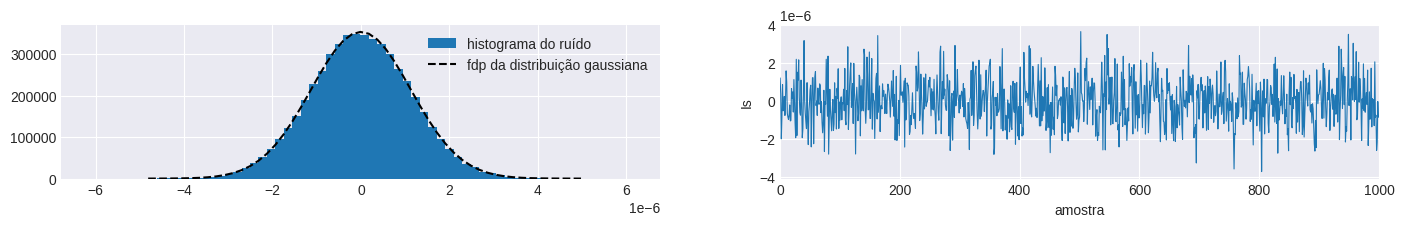

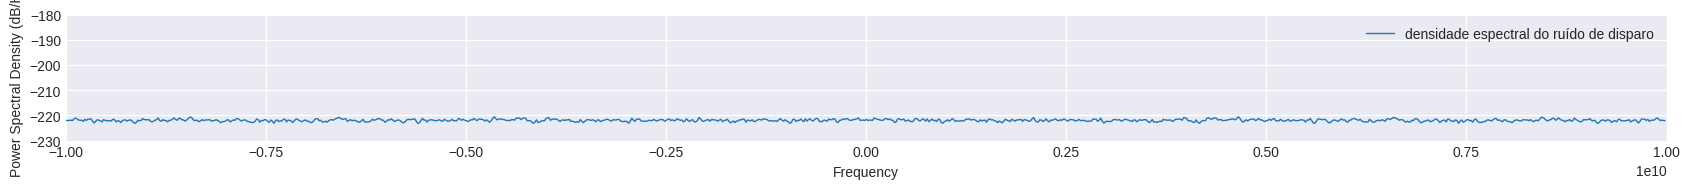

Potência do ruído (em W)   = 1.27e-12 W
Potência do ruído (em dBm) = -88.96 dBm


In [ ]:
# Configurando os gráficos.
plt.style.use("seaborn-v0_8-darkgrid")
fig, axes = plt.subplots(1, 2, figsize = (17,2))

count, bins, ignored = axes[0].hist(Is,51, density=True, label = "histograma do ruído")
fdp = gaussian(bins,μ,σ)

axes[0].plot(bins,fdp,"k--",label ="fdp da distribuição gaussiana")
axes[0].legend()
axes[0].set_xlim(-6*σ,6*σ)

# plotas as primeiras 1000 amostras
axes[1].plot(Is[0:1000],linewidth = 0.8)
axes[1].set_xlim(0,1000)
axes[1].set_ylabel("Is")
axes[1].set_xlabel("amostra")

plt.figure()
plt.xlim(-fa/2, fa/2)
plt.ylim(-230, -180)
plt.psd(Is, Fs=fa, label="densidade espectral do ruído de disparo",linewidth=1,  sides="twosided", NFFT=1024) # estima densidade espectral de potência do sinal
plt.legend()

display(Math("S_{i_s}(f) = %.2f \;\mathrm{dBW/Hz}"%(10*np.log10(σ2_s/(2*B)))))

plt.tight_layout()
plt.show()
Pn = signal_power(Is)

print("Potência do ruído (em W)   = %.2e W" %Pn)
print("Potência do ruído (em dBm) = %.2f dBm" %(10*np.log10(Pn/1e-3)))


### Ruído Térmico
---

O **ruído térmico**, gerado pela agitação térmica dos elétrons no receptor, sendo independente do sinal transmitido. Esse ruído também possui natureza aditiva, podendo ser modelado como um processo estocástico, gaussiano e estacionário, e portanto também classificado como ruído branco gaussiano.

A corrente total considerando todos os ruídos é:

$$
I(t) = I_p(t) + I_s(t) + I_T(t)
$$

A densidade espectral de potência do ruído térmico é constante e dada por:

$$
S_T(f) = \frac{2K_bT}{R_L}
$$

e a potência do ruído corresponde a sua variância $\sigma_T^2$ que é dado por:

$$
\sigma_T^2 = \left( \frac{4K_bT}{R_L} \right) B
$$

onde:
- $K_b$ é a constante de Boltzmann,
- $ T$ é a temperatura em Kelvin,
- $R_L$ é o resistor de carga do circuito.

Em nosso circuito, os amplificadores também podem introduzir ruídos térmicos adicionais. Esses ruídos são genericamente caracterizados pelo fator de ruído $F_n$, que introduz um ganho multiplicativo à expressão da variância do ruído térmico, resultando em:

$$
\sigma_T^2 = \left( \frac{4K_bT}{R_L} \right) F_n B
$$

<IPython.core.display.Math object>

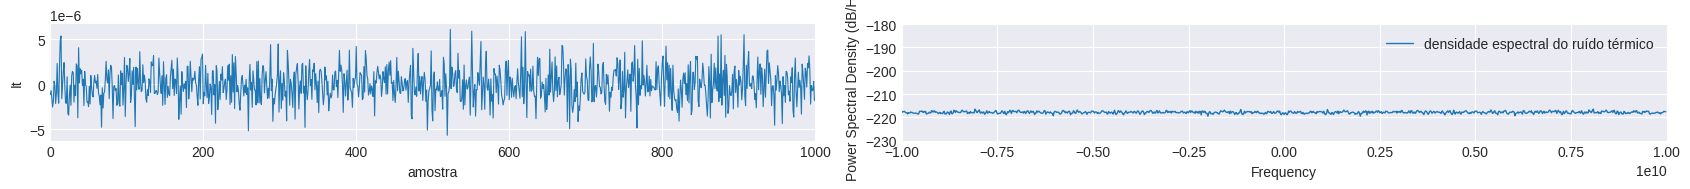

Potência do ruído (em W)   = 3.29e-12 W
Potência do ruído (em dBm) = -84.83 dBm


In [ ]:
Tc = 25                                                 # temperatura em Celsius
B  = 10e9                                                    # banda do receptor
RL = 50                                                             # RL em Ohms
T = Tc + 273.15                                          # temperatura em Kelvin
fa = 20e9                                 # frequência de amostragem considerada
kB  = constants.value("Boltzmann constant")

# ruído térmico (ruído gaussiano branco)
Namostras = 100000
σ2_T = 4*kB*T*B/RL
μ = 0

σ = np.sqrt(σ2_T)
It = normal(μ, σ, Namostras)

fig, axes = plt.subplots(1, 2, figsize = (17, 2))

# plotas as primeiras 1000 amostras
axes[0].plot(It[0:1000],linewidth = 0.8)
axes[0].set_xlim(0,1000)
axes[0].set_ylabel("It")
axes[0].set_xlabel("amostra")

axes[1].set_xlim(-fa/2, fa/2)
axes[1].set_ylim(-230, -180)
axes[1].psd(It, Fs=fa, label="densidade espectral do ruído térmico",linewidth=1, sides="twosided", NFFT=1024) # estima densidade espectral do sinal
axes[1].legend()

display(Math("S_{i_T}(f) = %.2f \;\mathrm{dBW/Hz}"%(10*np.log10(σ2_T/(2*B)))))

plt.tight_layout()
plt.show()

Pn = signal_power(It)

print("Potência do ruído (em W)   = %.2e W" %Pn)
print("Potência do ruído (em dBm) = %.2f dBm" %(10*np.log10(Pn/1e-3)))

### Razão Sinal-Ruído (SNR)
---

A razão sinal-ruído (Signal-to-Noise Ratio – SNR) é uma das principais medidas de desempenho em sistemas de comunicações. Ela representa a relação entre a potência do sinal ($P_s$) útil recebido e a potência total do ruído($P_n$) em um dado sistema. Quanto maior essa razão, maior é a distinção entre o sinal e o ruído, o que implica melhor qualidade na recepção e menor probabilidade de erro na decodificação das informações.

Matematicamente, a SNR pode ser definida como:

$$
SNR = \frac{P_s}{P_n}
$$
onde a parte teórica é $P_s = E[|I_p(t)|^2]$ e $P_n = \sigma_T^2 + \sigma_T^2$

Que pode ser expressa em decibéis (dB) como:

$$
SNR_{db} = 10 log_{10}P_s - 10 log_{10}P_n
$$

Para receptores p-i-n nossa expressão fica:

$$
SNR = \frac{R_d^2P_{in}^2}{2q(R_dP_{in} + I_d)B +  
4\left( \frac{K_bT}{R_L} \right) F_n B}
$$

onde a parte simulada temos $P_s = E[|I_p(t)|^2]$ e $P_n = E[|I_s(t)^2 + I_T(t)^2|]$

Potência média do sinal óptico modulado (mW): 0.01 mW
Potência média do sinal óptico modulado (dBm): -20.00 dBm


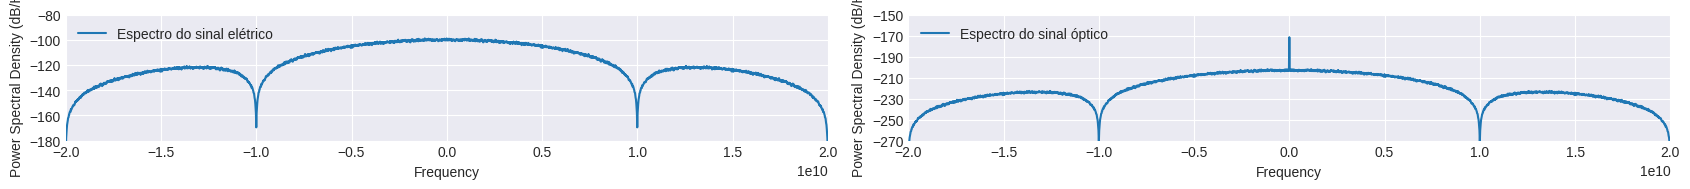

In [ ]:
# parâmetros da simulação
SpS = 16                                     # Parametros de amostra por simbolo
Rs     = 10e9                    # Taxa de símbolos (para o caso do OOK Rs = Rb)
Ts     = 1/Rs                                   # Período de símbolo em segundos
Fa     = 1/(Ts/SpS)       # Frequência de amostragem do sinal (amostras/segundo)
Ta     = 1/Fa                                            # Período de amostragem
Pi_dBm = -17           # potência de sinal óptico na entrada do modulador em dBm

# parâmetros do MZM
paramMZM = parameters()
paramMZM.Vpi = 2
paramMZM.Vb = -paramMZM.Vpi/2
Pi = 10**(Pi_dBm/10)*1e-3      # potência de sinal óptico em W na entrada do MZM

# gera sequência de bits pseudo-aleatórios
bits = np.random.randint(2, size=100000)
n = np.arange(0, bits.size)

# mapeia bits para pulsos elétricos
symb = 2*bits-1
symb = symb/np.sqrt(signal_power(symb))
symbolsUp = upsample(symb, SpS)

# pulso NRZ típico e formatação
pulse = pulseShape("nrz", SpS)
pulse = pulse/max(abs(pulse))
sigft  = firFilter(pulse, symbolsUp)

# modulação óptica
Ai = np.sqrt(Pi)
sigft0 = mzm(Ai, -paramMZM.Vb*0.5*sigft, paramMZM)

print("Potência média do sinal óptico modulado (mW): %.2f mW"%(signal_power(sigft0)/1e-3))
print("Potência média do sinal óptico modulado (dBm): %.2f dBm"%(10*np.log10(signal_power(sigft0)/1e-3)))

# plotando os graficos psd
fig, axes = plt.subplots(1, 2, figsize = (17,2))

axes[0].set_xlim(-2*Rs,2*Rs);
axes[0].set_ylim(-180,-80);
axes[0].psd(sigft,Fs=Fa, NFFT = 16*1024, sides="twosided", label = "Espectro do sinal elétrico")
axes[0].legend(loc="upper left");

axes[1].set_xlim(-2*Rs,2*Rs);
axes[1].set_ylim(-270,-150);
axes[1].psd(np.abs(sigft0)**2,Fs=Fa, NFFT = 16*1024, sides="twosided", label = "Espectro do sinal óptico")
axes[1].legend(loc="upper left");

plt.tight_layout()
plt.show()

In [ ]:
# parâmetros do receptor
Tc = 25                                                 # temperatura em Celsius
B  = 10e9                                              # banda do receptor em Hz
Rd  = 0.85                                               # responsividade em A/W
Id = 5e-9                                             # corrente de escuro em nA
RL = 50                                                             # RL em Ohms
Pin = (np.abs(sigft0)**2).mean()          # Potência óptica média média recebida

# fotocorrente livre de ruído
Ip = Rd*np.abs(sigft0)**2

# gerando ruidos
σ2_s = 2*q*(Rd*Pin + Id)*B
T = Tc + 273.15
σ2_T = 4*kB*T*B/RL

# adiciona ruído do receptor p-i-n aos sinais
Is = normal(0, np.sqrt(Fa*(σ2_s/(2*B))), Ip.size)
It = normal(0, np.sqrt(Fa*(σ2_T/(2*B))), Ip.size)

# Organizando os paramentros em uma função.
paramPD = parameters()
paramPD.Rd = Rd                                          # responsividade em A/W
paramPD.Tc = Tc                                         # temperatura em Celsius
paramPD.Id = Id                                        # corrente de escuro em A
paramPD.RL = RL                                                     # RL em Ohms
paramPD.B = B                                              # Largura de banda Hz
paramPD.Fs = Fa
paramPD.ideal = False
Ift = photodiode(sigft0, paramPD)

# Gerando um filtro passa-baixa
N = 8001
h = lowPassFIR(B, Fa, N, typeF="rect")
freq = fftshift(fftfreq(h.size, d=1/Fa))

# calculando as correntes na simulação SNR
Ipft  = firFilter(h, Ip)
Isft  = firFilter(h, Is)
Itft  = firFilter(h, It)

# SNR teórica e simulado
SNR_t  = (Ip**2).mean()/(σ2_s + σ2_T)
SNR_s = (Ipft**2).mean()/(Isft**2 + Itft**2).mean()

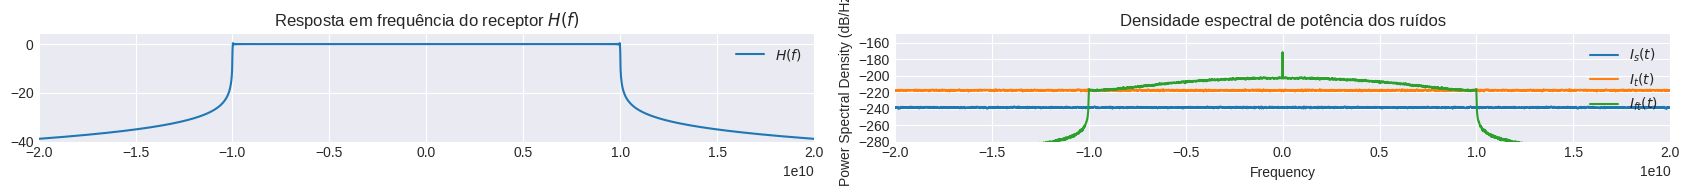

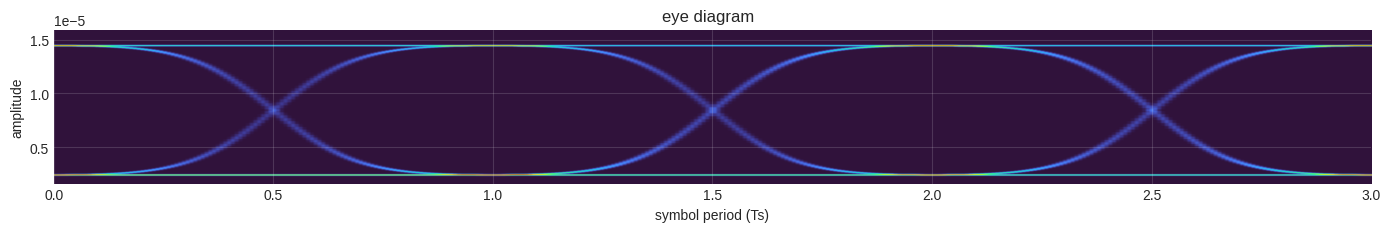

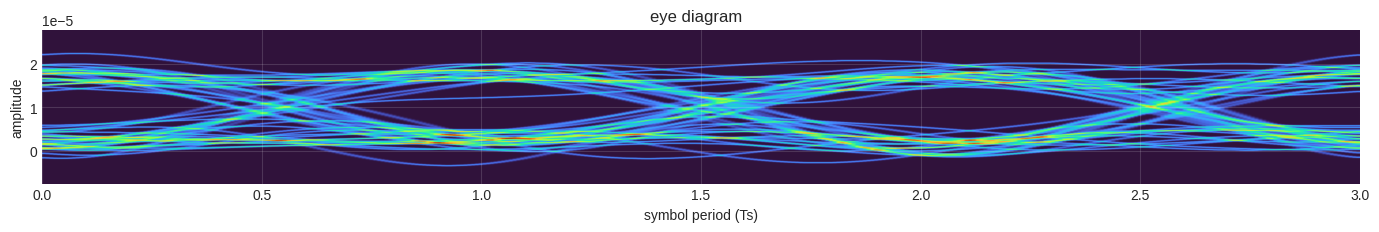

Pin = -20.00 dBm 
SNR[teorico] = 14.87 dB 
SNR[simulado] = 14.86 dB 


In [ ]:
# Configuração dos plots para analise das saídas:
fig , axes = plt.subplots(1, 2, figsize = (17,2))

axes[0].plot(freq, 10*np.log10(np.abs(fftshift(fft(h)))),label="$H(f)$")
axes[0].legend(loc="best")
axes[0].set_xlim(-2*Rs,2*Rs)
axes[0].set_ylim(-40,4)
axes[0].set_title("Resposta em frequência do receptor $H(f)$")

axes[1].set_xlim(-2*Rs,2*Rs)
axes[1].set_ylim(-280,-150)
axes[1].psd(Is, Fs=Fa, NFFT = 16*1024, sides="twosided", label = "$I_s(t)$")
axes[1].psd(It, Fs=Fa, NFFT = 16*1024, sides="twosided", label = "$I_t(t)$")
axes[1].psd(Ift, Fs=Fa, NFFT = 16*1024, sides="twosided", label = "$I_{ft}(t)$")
axes[1].set_title("Densidade espectral de potência dos ruídos")
axes[1].legend(loc="best")

plt.tight_layout()
plt.show()

eyediagram(Ip, Ip.size-SpS, SpS, ptype = "fancy")
eyediagram(Ift, Ift.size-SpS, SpS, ptype = "fancy")

print("Pin = %.2f dBm "%(10*np.log10(Pin/1e-3)))
print("SNR[teorico] = %.2f dB "%(10*np.log10(SNR_t)))
print("SNR[simulado] = %.2f dB "%(10*np.log10(SNR_s)))

### Conclusão
---

Após analisar os códigos e resultados obtidos, podemos concluir que a simulação apresentou um comportamento coerente com o esperado. O diagrama de olho mostra um leve nível de ruído, porém o olho permanece praticamente aberto, indicando uma boa margem para detecção, mesmo com uma razão de extinção relativamente baixa.

A estimativa simulada da razão sinal-ruído (SNR) ficou muito próxima do valor teórico, validando tanto a modelagem do sistema quanto a adição realista dos ruídos de disparo e térmico no receptor. Observamos uma entrada com potência óptica de -17 dBm e uma saída com -20,00 dBm, representando uma atenuação de aproximadamente -3 dB, exatamente como previsto, confirmando a consistência do modelo da modulação óptica via MZM.

Além disso, conseguimos simular com sucesso as correntes geradas no receptor p-i-n, o que facilitou a compreensão do impacto de cada componente (sinal, ruído de disparo, ruído térmico) no desempenho final do sistema, e proporcionou uma análise mais concreta do funcionamento do receptor óptico.


### Sensitividade de receptores
---

Esses ruídos podem causar diversos erros durante a transmissão dos dados. Uma das técnicas mais utilizadas para avaliar a fidelidade da comunicação é a medição da taxa de erro de bits (bit-error rate – BER), que indica com que frequência o circuito decisor comete erros na identificação dos bits transmitidos. Em sistemas práticos de comunicação óptica, é comum estabelecer limites como BER < 10⁻⁹ ou até BER < 10⁻¹² para garantir confiabilidade.

A BER está diretamente relacionada com a razão sinal-ruído (SNR), que por sua vez depende da potência óptica recebida Pin. A sensitividade de um receptor óptico é definida como o menor valor de potência recebida necessário para atingir uma BER aceitável. É importante destacar que, em sistemas reais, essa potência é afetada pela atenuação causada pela propagação do sinal ao longo da fibra óptica.

No contexto do canal AWGN (Additive White Gaussian Noise), o sinal recebido pode ser modelado como $y(n)=x(n)+n(t)$, onde $x(n)$ é o sinal transmitido e $n(t)$ é o ruído aditivo. Esse sinal recebido $y(t)$ deve passar por um filtro $h(t)$, como explorado nas simulações anteriores. O objetivo do filtro é maximizar a SNR na saída, permitindo que o circuito decisor identifique corretamente os bits transmitidos. O processo envolve a convolução do sinal com o filtro, levando em conta o comportamento estocástico do ruído, que após realizar todos os cálculos chegamos a seguite expressão final.

$$
SNR = \frac{P_s}{P_n} = \frac{E[s_k^2]
\left(\int_{-∞}^{∞}p(τ-kT_s) h(kT_s - τ)\right)dτ}
{\sigma_n^2\int_{-∞}^{∞}h^2(kT_s - τ)dτ}
$$

Para otimizar essa relação SNR, busca-se o filtro casado, que é obtido a partir do teorema da desigualdade de Cauchy-Schwarz. Esse teorema mostra que existe uma forma ótima de projetar $h(t)$ tal que a saída do filtro maximize a separação entre os níveis do sinal e o ruído. Na prática, essa escolha se reflete visualmente na abertura do diagrama de olho: quanto mais concentrado e aberto estiver o olho, menor a probabilidade de erro na detecção e melhor a razão de extinção. Portanto garante-se um SNR máximo e igual a:

$$
SNR = \frac{E[s_k^2]}{\sigma_n^2}\int_{-∞}^{∞}p^2(τ-kT_s)dτ
$$


### Decisor ótimo: avaliando probabilidades
---

A função do decisor é fornecer uma estimativa do bit transmitido a partir da observação $y(t)$. Ele adota uma regra que minimiza a probabilidade de erro na decisão do bit correto. Essa regra se baseia na probabilidade a posteriori, ou seja, na probabilidade do bit $b_k$ dado o valor observado $y_k$. Usando o Teorema de Bayes, temos a métrica de probabilidade a posteriori (MP):

$$ MP(b_k,y_k) = p(b_k|y_k) = \frac{p(y_k|b_k)p(b_k)}{p(y_k)}$$

A primeira regra de decisão é então:

 - $MP(b_k = 1,\hat y_k) > MP(b_k = 0,y_k)$, decide-se $\hat b_k = 1$
 - $MP(b_k = 0,\hat y_k) > MP(b_k = 1,y_k)$, decide-se $\hat b_k = 0$

Assumindo que as probabilidades dos bits $p(b_k= 0)$ e $p(b_k=1)$ são iguais, e que $p(y_k)$ é comum às duas hipóteses, podemos desprezar $p(y_k)$ na comparação, pois ele não afeta a decisão (mesmo denominador dos dois lados da desigualdade). Após manipulações algébricas e aplicação de estatística Bayesiana com ruído gaussiano, chegamos ao limiar de decisão ótimo $I_d$:

$$I_d = \frac{\sigma_0I_1 + \sigma_1I_0}{\sigma_0 + \sigma_1}$$
Com isso, temos a regra final:
 - Se $\hat y_k > I_d$ , decide-se $\hat b_k = 1$
 - Se $\hat y_k < I_d$ , decide-se $\hat b_k = 0$

#### Probabilidade de erro de bit $P_b$

A probabilidade de erro de bit $P_b$ representa a chance de que o bit detectado $\hat b_k$ seja diferente do bit transmitido $b_k$. Mesmo que $\hat b_k$ seja a melhor estimativa possível com base no valor observado $y_k$, é necessário considerar as diversas fontes de ruído e variações estatísticas que podem afetar a decisão.

Após manipulações algébricas e estatísticas, encontramos a seguinte expressão para $P_b$:

$$P_b = \frac{1}{2}erfc\left(\frac{Q}{\sqrt{2}}\right) ≈
\frac{exp(-Q^2/2)}{Q\sqrt{2}}$$

Onde:
$$ Q \equiv  \frac{I_1 - I_0}{\sigma_0 + \sigma_1}$$

$Q$ representa a razão entre a separação dos níveis médios do sinal, que pode ser também a razão de extinção e a soma das dispersões do ruído, ou seja, quanto maior a razão de extinção e menor o ruído, menor a probabilidade de erro.

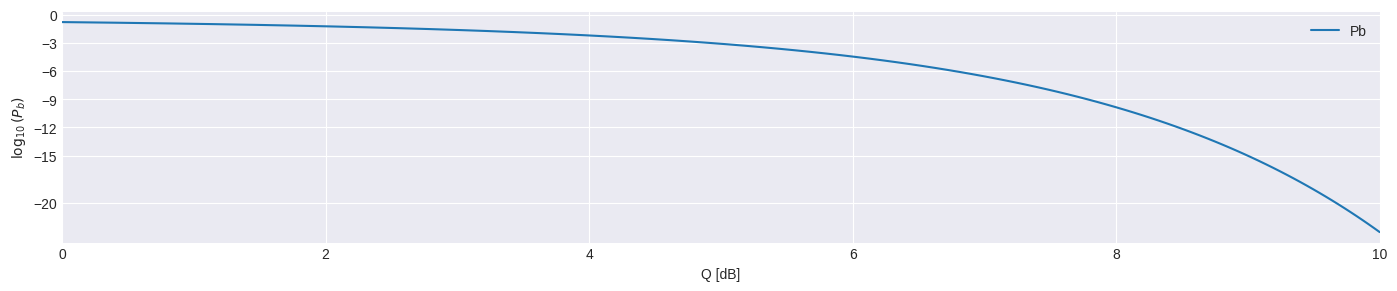

In [ ]:
from scipy.special import erfc

Q  = np.arange(1, 10.1, 0.1)
QdB = 10*np.log10(Q)
Pb = 0.5*erfc(Q/np.sqrt(2))

plt.figure(figsize=(17,3))
plt.plot(QdB, np.log10(Pb),label="Pb")
plt.xlabel("Q [dB]")
plt.ylabel("$\log_{10}(P_b)$");
plt.xlim(min(QdB),max(QdB))
plt.yticks([-20,-15, -12, -9, -6,-3, 0])
plt.legend()
plt.show()

In [ ]:
#Utilizando os códigos gerados acima iremos implementar os assuntos abordados nesta seção:
SNR_s = np.var(Ipft)/(np.var(Isft) + np.var(Itft))
Ift = Ift/np.std(Ift)
discard = 100

# gera sinal para visualização do diagrama de olho
I_eye = Ift[discard*SpS:Ift.size-discard*SpS]

# captura amostras no meio dos intervalos de sinalização
Ift  = Ift[0::SpS]

I1 = np.mean(Ift[bits==1])                                   # valor médio de I1
I0 = np.mean(Ift[bits==0])                                   # valor médio de I0
σ1 = np.std(Ift[bits==1])                               # desvio padrão σ1 de I1
σ0 = np.std(Ift[bits==0])                               # desvio padrão σ0 de I0
Id = (σ1*I0 + σ0*I1)/(σ1 + σ0)                         # limiar de decisão ótimo
Q  = (I1-I0)/(σ1 + σ0)                                                 # fator Q

# Aplica a regra de decisão ótima
bitsft = np.empty(bits.size)
bitsft[Ift>  Id] = 1
bitsft[Ift<= Id] = 0

err = np.logical_xor(bitsft[discard:bitsft.size-discard], bits[discard:bits.size-discard])
BER = np.mean(err)

Pb = 0.5*erfc(Q/np.sqrt(2)) # probabilidade de erro teórica

Pin = -20.00 dBm 
SNR[sim] = 9.49 dB 

Parâmetros do diagrama de olho:
I0 = 0.34  
I1 = 2.66  
σ0 = 0.28  
σ1 = 0.28  
Limiar ótimo Id = 1.50  
Q = 4.16   

Total de erros contados = 2  
BER = 2.00e-05  
Pb = 1.56e-05  


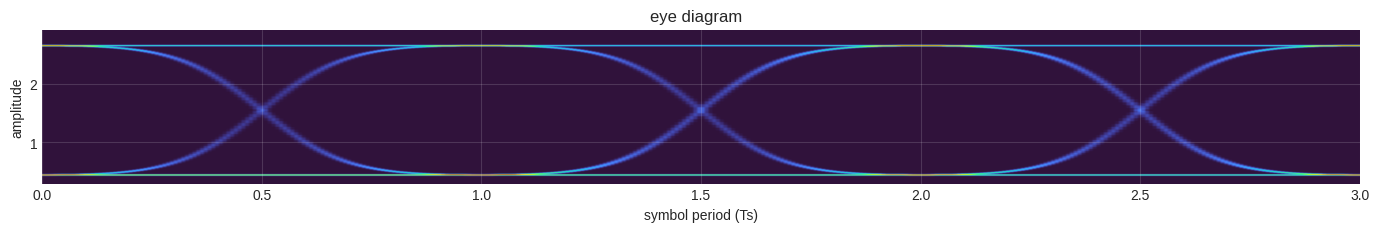

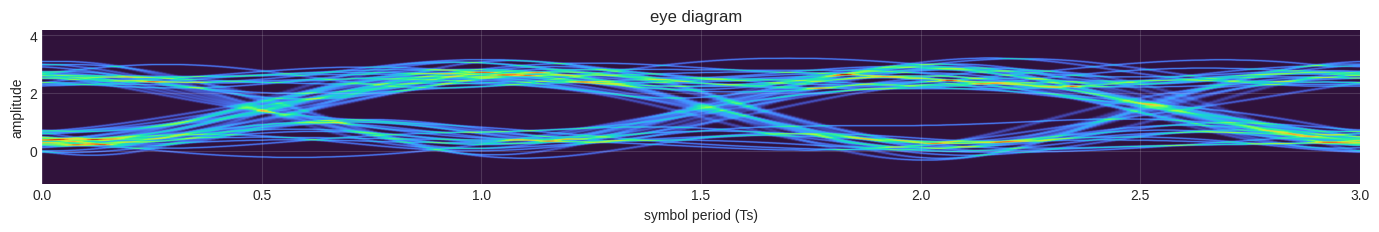

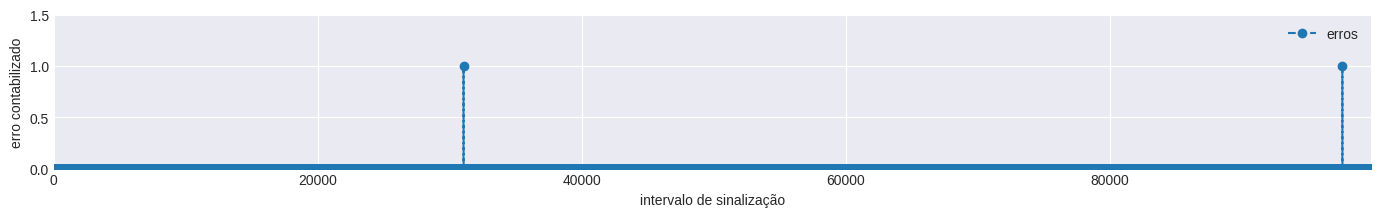

In [ ]:
print("Pin = %.2f dBm "%(10*np.log10(Pin/1e-3)))
print("SNR[sim] = %.2f dB \n"%(10*np.log10(SNR_s)))
print("Parâmetros do diagrama de olho:")
print("I0 = %.2f  "%(I0))
print("I1 = %.2f  "%(I1))
print("σ0 = %.2f  "%(σ0))
print("σ1 = %.2f  "%(σ1))
print("Limiar ótimo Id = %.2f  "%(Id))
print("Q = %.2f   \n"%(Q))
print("Total de erros contados = %d  "%(err.sum()))
print("BER = %.2e  "%(BER))
print("Pb = %.2e  "%(Pb))

eyediagram(Ip/np.std(Ip),  Ip.size-SpS, SpS, ptype="fancy")
eyediagram(I_eye/np.std(I_eye), I_eye.size-SpS, SpS, ptype="fancy")

plt.plot(err,"--o",label = "erros")
plt.xlabel("intervalo de sinalização")
plt.ylabel("erro contabilizado")
plt.legend()
plt.ylim(0, 1.5)
plt.xlim(0,err.size)
plt.show()

### Referências
---
1. **Bibliotecas de Numpy**. *Numpy*. Disponível em: [https://numpy.org/devdocs/reference/routines.html](https://numpy.org/devdocs/reference/routines.html).   Acessado em: 29 de abril de 2025.
2. **OpticalCommunications**. *Edson porto da Silva*. Disponível em: [https://github.com/edsonportosilva/OpticalCommunications/...notebooks](https://github.com/edsonportosilva/OpticalCommunications/tree/main/jupyter%20notebooks). Acessado em: 28 de abril de 2025.